In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import math

plt.style.use('seaborn-v0_8') # I personally prefer seaborn for the graph style, but you may choose whichever you want.
params = {"ytick.color" : "black",
          "xtick.color" : "black",
          "axes.labelcolor" : "black",
          "axes.edgecolor" : "black",
          "text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"]}
plt.rcParams.update(params)

output_dir = "/Users/russell/projects/stencil_research/fft_bench/plots"

In [9]:
warmup_iter = 2
xlow = 1000
xhi = 14000

results_dirs = [
    "/Users/russell/projects/stencil_research/fft_bench/results/expanse_3",
]

plan_data = {
    "Estimate": {},
    "Measure": {},
    "MKL_OUT_OF_PLACE": {},
}

def load_results_file(path):
    with open(json_path, 'r') as json_file:
        data = json.load(json_file)
        plan_type = data["plan_type"]
        plan_size = data["plan_size"]
        if plan_size < xlow or plan_size > xhi:
            return
        time = np.average(data["timings"][warmup_iter:])
        plan_data[plan_type][plan_size] = time
        
for results_dir in results_dirs:  
    for file in sorted(os.listdir(results_dir)):
        json_path = f"{results_dir}/{file}"
        load_results_file(json_path)

In [10]:
plot_data = {}
for plan_type in plan_data.keys():
    name = plan_type
    plan_sizes = sorted(plan_data[plan_type].keys())
    times = [plan_data[plan_type][plan_size] for plan_size in plan_sizes]
    plot_data[name] = {}
    plot_data[name]["plan_sizes"] = plan_sizes
    plot_data[name]["times"] = times

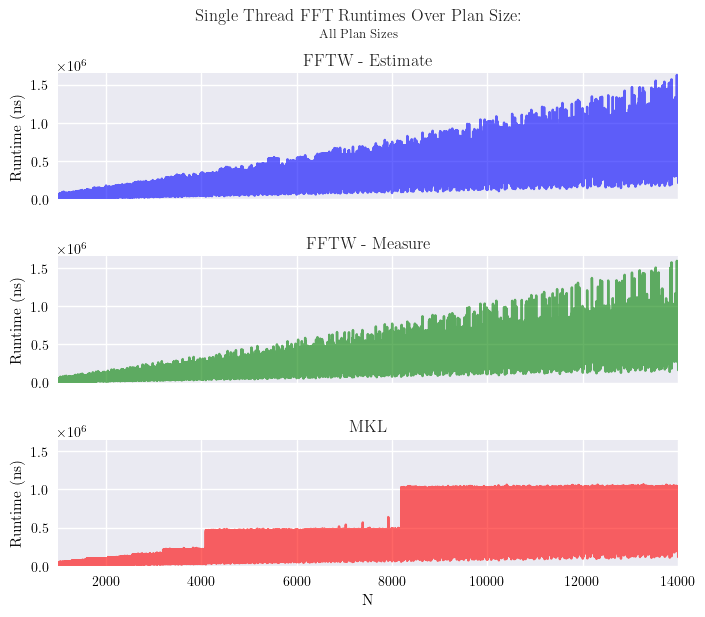

In [11]:
width = 8
height_ratio = 0.8
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 3
n_cols = 1
width_ratios = [1.0]
height_ratios = [1.0, 1.0, 1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.45,
    hspace = 0.45,
)
ax_1 = fig.add_subplot(gs1[0, 0])
ax_2 = fig.add_subplot(gs1[1, 0])
ax_3 = fig.add_subplot(gs1[2, 0])

ylow = 0
yhi = 1650000
plan_type = "Estimate"
ax_1.plot(
    plot_data[plan_type]["plan_sizes"], 
    plot_data[plan_type]["times"], 
    color="blue",
    alpha = 0.6
)
ax_1.set_xticklabels([])
ax_1.set_ylabel("Runtime (ns)")
ax_1.set_title("FFTW - Estimate")
ax_1.set_ylim(ylow, yhi)
ax_1.set_xlim(xlow, xhi)

plan_type = "Measure"
ax_2.plot(
    plot_data[plan_type]["plan_sizes"], 
    plot_data[plan_type]["times"], 
    color="green",
    alpha = 0.6
)
ax_2.set_xticklabels([])
ax_2.set_ylabel("Runtime (ns)")
ax_2.set_title("FFTW - Measure")
ax_2.set_ylim(ylow, yhi)
ax_2.set_xlim(xlow, xhi)

plan_type = "MKL_OUT_OF_PLACE"
ax_3.plot(
    plot_data[plan_type]["plan_sizes"], 
    plot_data[plan_type]["times"], 
    color="red",
    alpha = 0.6
)
ax_3.set_ylabel("Runtime (ns)")
ax_3.set_xlabel("N")
ax_3.set_title("MKL")
ax_3.set_ylim(ylow, yhi)
ax_3.set_xlim(xlow, xhi)

fig.suptitle("Single Thread FFT Runtimes Over Plan Size:\n {\small All Plan Sizes}")
plt.savefig(f"{output_dir}/exp3_overview.pdf")